# Multi-Turn Visual Product Analyst Agent
## Gemma 4 31B-IT | Vision + Function Calling + Thinking Mode

This notebook demonstrates a **multi-turn visual agent** that:
1. Receives product image(s) from the user
2. Iteratively analyzes them using Gemma 4's vision capabilities
3. Calls tools (search, price lookup, reviews, specs) to gather information
4. Uses **thinking mode** for reasoning through each step
5. Produces a structured product analysis report

**Architecture:** Explicit agent loop (max 5 turns) with full conversation history.

**Hardware:** Requires ~65GB VRAM (bf16). Works on A100 80GB, H100, or RTX PRO 6000 Blackwell.

## 1. Setup

In [ ]:
!pip install -q transformers accelerate pillow requests matplotlib

In [15]:
import torch
import re
import json
import textwrap
from PIL import Image
from io import BytesIO
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, Markdown, HTML

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 102.0 GB


## 2. Load Gemma 4 31B-IT (bfloat16)

We load in bf16 without quantization. 4-bit quantization corrupts the vision encoder, causing the model to see images as solid gray. bf16 requires ~65GB VRAM but preserves full vision quality.

In [17]:
from transformers import AutoProcessor, AutoModelForMultimodalLM

MODEL_ID = "google/gemma-4-31B-it"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,
    device_map="auto",
)

print(f"Model loaded: {MODEL_ID}")
print(f"Model dtype: {model.dtype}")

Loading weights:   0%|          | 0/1188 [00:00<?, ?it/s]

Model loaded: google/gemma-4-31B-it
Model dtype: torch.bfloat16


## 3. Tool Definitions (Hybrid: Simulated + Swappable)

Each tool has a **simulated** implementation that returns realistic fake data, with a clearly marked swap point for real APIs. To use a real backend, replace the body of the inner function.

In [18]:
# ---------------------------------------------------------------------------
# Tool 1: search_product
# ---------------------------------------------------------------------------
def search_product(query: str) -> dict:
    """Searches for a product by name or description and returns matching results.

    Args:
        query: The product name or description to search for.
    """
    # --- SWAP POINT: Replace with real API (e.g., SerpAPI, Google Shopping) ---
    # Products keyed by specific model identifiers for precise matching
    simulated_db = [
        {"keys": ["wh-1000xm4", "xm4", "1000xm4"], "product_name": "Sony WH-1000XM4", "brand": "Sony", "category": "Over-ear Wireless Headphones", "match_confidence": 0.95},
        {"keys": ["wh-1000xm5", "xm5", "1000xm5"], "product_name": "Sony WH-1000XM5", "brand": "Sony", "category": "Over-ear Wireless Headphones", "match_confidence": 0.95},
        {"keys": ["wh-1000xm3", "xm3", "1000xm3"], "product_name": "Sony WH-1000XM3", "brand": "Sony", "category": "Over-ear Wireless Headphones", "match_confidence": 0.93},
        {"keys": ["wf-1000xm5", "wf-1000xm4", "earbuds", "in-ear"], "product_name": "Sony WF-1000XM5", "brand": "Sony", "category": "True Wireless Earbuds", "match_confidence": 0.92},
        {"keys": ["beats solo", "solo3", "solo 3"], "product_name": "Beats Solo3 Wireless", "brand": "Beats", "category": "On-ear Wireless Headphones", "match_confidence": 0.93},
        {"keys": ["beats studio", "studio3", "studio 3"], "product_name": "Beats Studio3 Wireless", "brand": "Beats", "category": "Over-ear Wireless Headphones", "match_confidence": 0.92},
        {"keys": ["beats solo4", "solo4", "solo 4"], "product_name": "Beats Solo 4", "brand": "Beats", "category": "On-ear Wireless Headphones", "match_confidence": 0.94},
        {"keys": ["airpods max"], "product_name": "Apple AirPods Max", "brand": "Apple", "category": "Over-ear Wireless Headphones", "match_confidence": 0.94},
        {"keys": ["airpods pro"], "product_name": "Apple AirPods Pro 2", "brand": "Apple", "category": "True Wireless Earbuds", "match_confidence": 0.93},
        {"keys": ["qc45", "quietcomfort 45", "quietcomfort45"], "product_name": "Bose QuietComfort 45", "brand": "Bose", "category": "Over-ear Wireless Headphones", "match_confidence": 0.94},
        {"keys": ["qc35", "quietcomfort 35", "quietcomfort35"], "product_name": "Bose QuietComfort 35 II", "brand": "Bose", "category": "Over-ear Wireless Headphones", "match_confidence": 0.93},
        {"keys": ["qc ultra", "quietcomfort ultra"], "product_name": "Bose QuietComfort Ultra", "brand": "Bose", "category": "Over-ear Wireless Headphones", "match_confidence": 0.95},
        {"keys": ["bose 700", "nc700", "nch700"], "product_name": "Bose Noise Cancelling Headphones 700", "brand": "Bose", "category": "Over-ear Wireless Headphones", "match_confidence": 0.94},
        {"keys": ["sennheiser momentum", "momentum 4"], "product_name": "Sennheiser Momentum 4 Wireless", "brand": "Sennheiser", "category": "Over-ear Wireless Headphones", "match_confidence": 0.92},
        {"keys": ["macbook air", "m3 air"], "product_name": "Apple MacBook Air M3 15-inch", "brand": "Apple", "category": "Laptop", "match_confidence": 0.91},
        {"keys": ["macbook pro", "m3 pro"], "product_name": "Apple MacBook Pro M3", "brand": "Apple", "category": "Laptop", "match_confidence": 0.92},
        {"keys": ["watch ultra"], "product_name": "Apple Watch Ultra 2", "brand": "Apple", "category": "Smartwatch", "match_confidence": 0.89},
        {"keys": ["apple watch", "watch series"], "product_name": "Apple Watch Series 9", "brand": "Apple", "category": "Smartwatch", "match_confidence": 0.88},
        {"keys": ["a7 iv", "a7iv", "alpha 7"], "product_name": "Sony A7 IV", "brand": "Sony", "category": "Mirrorless Camera", "match_confidence": 0.92},
        {"keys": ["keychron", "q1 pro"], "product_name": "Keychron Q1 Pro", "brand": "Keychron", "category": "Mechanical Keyboard", "match_confidence": 0.88},
        {"keys": ["mx master", "master 3s"], "product_name": "Logitech MX Master 3S", "brand": "Logitech", "category": "Wireless Mouse", "match_confidence": 0.93},
        {"keys": ["sonos era", "era 300"], "product_name": "Sonos Era 300", "brand": "Sonos", "category": "Smart Speaker", "match_confidence": 0.90},
        {"keys": ["ipad pro"], "product_name": "Apple iPad Pro M4", "brand": "Apple", "category": "Tablet", "match_confidence": 0.91},
        {"keys": ["galaxy s24", "s24 ultra"], "product_name": "Samsung Galaxy S24 Ultra", "brand": "Samsung", "category": "Smartphone", "match_confidence": 0.93},
        {"keys": ["pixel 8", "pixel 9"], "product_name": "Google Pixel 9 Pro", "brand": "Google", "category": "Smartphone", "match_confidence": 0.91},
    ]
    query_lower = query.lower()
    # First pass: match on specific model keys
    for product in simulated_db:
        for key in product["keys"]:
            if key in query_lower:
                return {k: v for k, v in product.items() if k != "keys"}
    # Second pass: match on brand name
    for product in simulated_db:
        if product["brand"].lower() in query_lower:
            return {k: v for k, v in product.items() if k != "keys"}
    # Fallback
    return {
        "product_name": query.title(),
        "brand": "Unknown",
        "category": "Electronics",
        "match_confidence": 0.60,
    }


# ---------------------------------------------------------------------------
# Tool 2: get_price
# ---------------------------------------------------------------------------
def get_price(product_name: str) -> dict:
    """Looks up the current price of a product across multiple retailers.

    Args:
        product_name: The exact product name to look up prices for.
    """
    # --- SWAP POINT: Replace with real price comparison API ---
    import hashlib
    seed = int(hashlib.md5(product_name.encode()).hexdigest()[:8], 16)
    base = 50 + (seed % 450)
    return {
        "product_name": product_name,
        "currency": "USD",
        "prices": [
            {"retailer": "Amazon", "price": round(base * 1.0, 2), "in_stock": True},
            {"retailer": "Best Buy", "price": round(base * 1.05, 2), "in_stock": True},
            {"retailer": "B&H Photo", "price": round(base * 0.97, 2), "in_stock": seed % 3 != 0},
        ],
        "lowest_price": round(base * 0.97, 2),
    }


# ---------------------------------------------------------------------------
# Tool 3: get_reviews
# ---------------------------------------------------------------------------
def get_reviews(product_name: str) -> dict:
    """Gets review ratings and summary for a product.

    Args:
        product_name: The exact product name to look up reviews for.
    """
    # --- SWAP POINT: Replace with real review API ---
    import hashlib
    seed = int(hashlib.md5(product_name.encode()).hexdigest()[:8], 16)
    rating = round(3.5 + (seed % 15) / 10.0, 1)
    rating = min(rating, 4.9)
    return {
        "product_name": product_name,
        "average_rating": rating,
        "total_reviews": 200 + (seed % 3000),
        "pros": ["Build quality", "Feature-rich", "Good value for price"],
        "cons": ["Could be lighter", "Learning curve for some features"],
        "summary": f"{product_name} is well-regarded with a {rating}/5 rating. "
                   f"Users praise build quality and features.",
    }


# ---------------------------------------------------------------------------
# Tool 4: get_specs
# ---------------------------------------------------------------------------
def get_specs(product_name: str) -> dict:
    """Gets detailed technical specifications for a product.

    Args:
        product_name: The exact product name to look up specifications for.
    """
    # --- SWAP POINT: Replace with real specs API ---
    specs_db = {
        "Sony WH-1000XM4": {
            "driver_size": "40mm",
            "frequency_response": "4Hz-40kHz",
            "battery_life": "30 hours",
            "weight": "254g",
            "noise_cancellation": "Dual Noise Sensor with Adaptive Sound Control",
            "connectivity": "Bluetooth 5.0, NFC, 3.5mm, USB-C",
            "codecs": "SBC, AAC, LDAC",
        },
        "Sony WH-1000XM5": {
            "driver_size": "30mm",
            "frequency_response": "4Hz-40kHz",
            "battery_life": "30 hours",
            "weight": "250g",
            "noise_cancellation": "Adaptive ANC with Auto NC Optimizer",
            "connectivity": "Bluetooth 5.2, 3.5mm, USB-C",
            "codecs": "SBC, AAC, LDAC",
        },
        "Beats Solo3 Wireless": {
            "driver_size": "Custom 40mm",
            "frequency_response": "20Hz-31kHz",
            "battery_life": "40 hours",
            "weight": "215g",
            "noise_cancellation": "None (passive isolation)",
            "connectivity": "Bluetooth, Apple W1 chip, 3.5mm",
            "codecs": "SBC, AAC",
            "fast_fuel": "5 min charge = 3 hours playback",
        },
        "Beats Solo 4": {
            "driver_size": "Custom 40mm transducer",
            "frequency_response": "20Hz-20kHz",
            "battery_life": "50 hours",
            "weight": "217g",
            "noise_cancellation": "None (passive isolation)",
            "connectivity": "Bluetooth 5.3, USB-C audio, 3.5mm",
            "codecs": "SBC, AAC, Lossless via USB-C",
            "spatial_audio": "Personalized Spatial Audio with head tracking",
        },
        "Bose QuietComfort 45": {
            "driver_size": "35mm",
            "battery_life": "24 hours",
            "weight": "240g",
            "noise_cancellation": "Active with Aware mode",
            "connectivity": "Bluetooth 5.1, 3.5mm, USB-C",
            "codecs": "SBC, AAC",
        },
        "Bose QuietComfort Ultra": {
            "driver_size": "35mm",
            "battery_life": "24 hours",
            "weight": "250g",
            "noise_cancellation": "CustomTune ANC",
            "connectivity": "Bluetooth 5.3, 3.5mm, USB-C",
            "codecs": "SBC, AAC, aptX Adaptive",
            "spatial_audio": "Bose Immersive Audio",
        },
        "Apple AirPods Max": {
            "driver_size": "40mm Apple-designed",
            "battery_life": "20 hours",
            "weight": "384.8g",
            "noise_cancellation": "Active with Transparency mode",
            "connectivity": "Bluetooth 5.0, Lightning/USB-C",
            "chip": "Apple H1",
            "spatial_audio": "Personalized Spatial Audio with head tracking",
        },
        "Apple MacBook Air M3 15-inch": {
            "processor": "Apple M3 (8-core CPU, 10-core GPU)",
            "ram": "8GB unified memory",
            "storage": "256GB SSD",
            "display": "15.3-inch Liquid Retina, 2880x1864",
            "battery_life": "18 hours",
            "weight": "1.51 kg",
            "ports": "2x Thunderbolt/USB 4, MagSafe, 3.5mm",
        },
        "Apple Watch Ultra 2": {
            "chip": "S9 SiP",
            "display": "49mm Always-On Retina LTPO OLED, 3000 nits",
            "battery_life": "36 hours (72h low power)",
            "water_resistance": "100m / EN 13319",
            "connectivity": "GPS L1/L5, LTE, UWB, Bluetooth 5.3",
            "weight": "61.4g",
        },
    }
    if product_name in specs_db:
        return {"product_name": product_name, "specs": specs_db[product_name]}
    return {
        "product_name": product_name,
        "specs": {
            "note": "Detailed specs not found in database.",
            "category": "Consumer Electronics",
        },
    }


print("Tools defined: search_product, get_price, get_reviews, get_specs")

Tools defined: search_product, get_price, get_reviews, get_specs


## 4. Tool Registry and Function-Calling Schema

We register tools in a dispatch table and use Gemma 4's native function-calling format via the processor's chat template.

In [19]:
# Tool dispatch table -- maps function names to callables
TOOL_REGISTRY = {
    "search_product": search_product,
    "get_price": get_price,
    "get_reviews": get_reviews,
    "get_specs": get_specs,
}

# The list of tool functions to pass to apply_chat_template.
# Gemma 4's processor auto-extracts schemas from Python functions
# (using type hints + Google-style docstrings).
TOOLS = list(TOOL_REGISTRY.values())

print(f"Registered {len(TOOLS)} tools: {list(TOOL_REGISTRY.keys())}")

Registered 4 tools: ['search_product', 'get_price', 'get_reviews', 'get_specs']


## 5. Agent Core: Tool Call Parsing and Generation Helpers

In [20]:
def extract_tool_calls(text: str) -> list[dict]:
    """Parse Gemma 4 tool-call tokens into structured dicts."""
    def cast(v):
        try:
            return int(v)
        except ValueError:
            try:
                return float(v)
            except ValueError:
                return {"true": True, "false": False}.get(
                    v.lower(), v.strip("'\"")
                )

    return [
        {
            "name": name,
            "arguments": {
                k: cast((v1 or v2).strip())
                for k, v1, v2 in re.findall(
                    r'(\w+):(?:<\|"\|>(.*?)<\|"\|>|([^,}]*))', args
                )
            },
        }
        for name, args in re.findall(
            r"<\|tool_call>call:(\w+)\{(.*?)\}<tool_call\|>", text, re.DOTALL
        )
    ]


def execute_tool_calls(calls: list[dict]) -> list[dict]:
    """Execute parsed tool calls and return results."""
    results = []
    for call in calls:
        fn = TOOL_REGISTRY.get(call["name"])
        if fn is None:
            results.append({"name": call["name"], "response": {"error": "Unknown tool"}})
            continue
        try:
            response = fn(**call["arguments"])
        except Exception as e:
            response = {"error": str(e)}
        results.append({"name": call["name"], "response": response})
    return results


def generate(messages: list[dict], images: list[Image.Image] = None, max_new_tokens: int = 2048) -> str:
    """Run one generation step with tools and thinking mode enabled.

    Uses a two-step approach:
    1. apply_chat_template(tokenize=False) to build the text prompt
    2. processor(text=..., images=...) to encode text + image pixels

    This is required because tokenize=True crashes on multi-turn
    conversations containing assistant tool_calls and tool role messages
    (the processor tries to iterate their content looking for images).
    """
    # Step 1: Build text prompt (handles tool schemas, thinking, etc.)
    text_prompt = processor.apply_chat_template(
        messages,
        tools=TOOLS,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=True,
    )

    # Step 2: Encode text + images together
    inputs = processor(
        text=text_prompt,
        images=images if images else None,
        return_tensors="pt",
    ).to(model.device)

    input_len = inputs["input_ids"].shape[-1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=1.0,
            top_p=0.95,
            top_k=64,
            do_sample=True,
        )
    raw = processor.decode(outputs[0][input_len:], skip_special_tokens=False)
    return raw


print("Agent core ready: extract_tool_calls, execute_tool_calls, generate")

Agent core ready: extract_tool_calls, execute_tool_calls, generate


## 6. The Agent Loop

The main agent function that orchestrates multi-turn reasoning:
1. Send image + user query
2. Model either calls a tool or responds with final answer
3. If tool call: execute, append results, loop
4. If final answer: return
5. Max 5 turns to prevent runaway loops

In [21]:
SYSTEM_PROMPT = """You are a Product Analyst Agent. When given product images, you:

1. FIRST: Look at the image carefully, identify the product, and call search_product.
2. THEN: Call get_price, get_reviews, and get_specs together in a single turn.
3. FINALLY: Produce a structured analysis report in markdown with:
   - Product identification (name, brand, category)
   - Price comparison table
   - Review summary (rating, pros, cons)
   - Key specifications
   - Your recommendation and value assessment

Be efficient: batch independent tool calls into one turn.
Do NOT make up prices or specs -- always use the tools."""


def load_image(source: str) -> Image.Image:
    """Load an image from a URL or local file path."""
    if source.startswith(("http://", "https://")):
        headers = {"User-Agent": "Mozilla/5.0 (compatible; ProductAnalystAgent/1.0)"}
        resp = requests.get(source, timeout=15, headers=headers)
        resp.raise_for_status()
        return Image.open(BytesIO(resp.content)).convert("RGB")
    return Image.open(source).convert("RGB")


def run_agent(
    image_sources: list[str],
    user_query: str,
    max_turns: int = 5,
    verbose: bool = True,
) -> dict:
    """Run the multi-turn visual product analyst agent."""
    pil_images = [load_image(src) for src in image_sources]

    user_content = [{"type": "image", "image": img} for img in pil_images]
    user_content.append({"type": "text", "text": user_query})

    messages = [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
        {"role": "user", "content": user_content},
    ]

    turns = []

    for turn_num in range(1, max_turns + 1):
        if verbose:
            print(f"\n{'='*60}")
            print(f"  TURN {turn_num}/{max_turns}")
            print(f"{'='*60}")

        raw_output = generate(messages, images=pil_images)
        parsed = processor.parse_response(raw_output)
        thinking = parsed.get("thinking", "")
        content = parsed.get("content", "")

        turn_record = {
            "turn": turn_num,
            "thinking": thinking,
            "tool_calls": [],
            "tool_results": [],
            "content": content,
        }

        if verbose and thinking:
            print(f"\n  Thinking: {thinking[:200]}{'...' if len(thinking) > 200 else ''}")

        raw_tool_calls = extract_tool_calls(raw_output)

        if raw_tool_calls:
            results = execute_tool_calls(raw_tool_calls)
            turn_record["tool_calls"] = raw_tool_calls
            turn_record["tool_results"] = results

            if verbose:
                for call, result in zip(raw_tool_calls, results):
                    print(f"  Tool: {call['name']}({call['arguments']})")
                    print(f"  Result: {json.dumps(result['response'], indent=2)[:300]}")

            messages.append({
                "role": "assistant",
                "tool_calls": [{"type": "function", "function": c} for c in raw_tool_calls],
            })
            for call, result in zip(raw_tool_calls, results):
                messages.append({
                    "role": "tool",
                    "name": call["name"],
                    "content": json.dumps(result["response"]),
                })

            turns.append(turn_record)
            continue

        if verbose:
            print(f"\n  Final answer generated ({len(content)} chars)")

        turns.append(turn_record)
        return {
            "final_answer": content,
            "turns": turns,
            "messages": messages,
            "total_turns": turn_num,
        }

    # Max turns reached
    if verbose:
        print(f"\n  Max turns ({max_turns}) reached. Requesting final summary...")

    messages.append({
        "role": "user",
        "content": [{"type": "text", "text":
            "Produce your final product analysis report now based on all gathered data."}],
    })
    raw_output = generate(messages, images=pil_images, max_new_tokens=2048)
    parsed = processor.parse_response(raw_output)
    final_content = parsed.get("content", raw_output)

    turns.append({
        "turn": max_turns + 1,
        "thinking": parsed.get("thinking", ""),
        "tool_calls": [],
        "tool_results": [],
        "content": final_content,
    })

    return {
        "final_answer": final_content,
        "turns": turns,
        "messages": messages,
        "total_turns": max_turns + 1,
    }


print("Agent loop ready.")

Agent loop ready.


## 7. Turn-by-Turn Visualization

In [22]:
def visualize_agent_trace(result: dict, images: list[Image.Image] = None):
    """Render a visual trace of the agent's multi-turn reasoning."""

    # Show input images
    if images:
        fig, axes = plt.subplots(1, len(images), figsize=(6 * len(images), 6))
        if len(images) == 1:
            axes = [axes]
        for ax, img in zip(axes, images):
            ax.imshow(img)
            ax.axis("off")
        fig.suptitle("Input Image(s)", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()

    # Turn-by-turn trace
    html_parts = ['<div style="font-family: monospace; max-width: 800px;">']
    html_parts.append('<h3>Agent Trace</h3>')

    for turn in result["turns"]:
        t = turn["turn"]
        html_parts.append(
            f'<div style="border-left: 3px solid #4285f4; padding: 8px 12px; '
            f'margin: 8px 0; background: #f8f9fa;">'
            f'<strong>Turn {t}</strong>'
        )

        if turn["thinking"]:
            short = turn["thinking"][:300].replace("<", "&lt;")
            html_parts.append(
                f'<div style="color: #666; margin: 4px 0;">'
                f'<em>Thinking:</em> {short}{"..." if len(turn["thinking"]) > 300 else ""}'
                f'</div>'
            )

        for call, res in zip(turn["tool_calls"], turn["tool_results"]):
            args_str = ", ".join(f"{k}={v!r}" for k, v in call["arguments"].items())
            html_parts.append(
                f'<div style="color: #1a73e8; margin: 4px 0;">'
                f'<code>{call["name"]}({args_str})</code>'
                f'</div>'
            )
            res_short = json.dumps(res["response"], indent=2)[:200]
            html_parts.append(
                f'<div style="color: #188038; margin: 4px 0; '
                f'white-space: pre-wrap; font-size: 0.85em;">'
                f'{res_short}{"..." if len(json.dumps(res["response"])) > 200 else ""}'
                f'</div>'
            )

        if turn["content"]:
            html_parts.append(
                f'<div style="margin: 4px 0;"><strong>Response:</strong> '
                f'({len(turn["content"])} chars)</div>'
            )

        html_parts.append('</div>')

    html_parts.append(
        f'<div style="margin-top: 12px; padding: 8px; background: #e8f5e9; '
        f'border-radius: 4px;"><strong>Completed in {result["total_turns"]} '
        f'turn(s)</strong></div>'
    )
    html_parts.append('</div>')

    display(HTML("".join(html_parts)))

    # Final report
    display(Markdown("---\n## Final Report\n" + result["final_answer"]))


print("Visualization helper ready.")

Visualization helper ready.


## 8. Demo 1: Single Product Analysis

Let's give the agent a single product image and watch it work through identification, pricing, reviews, and specs.

**Note:** We use local placeholder images stored in `images/`. Replace with your own product photos or URLs for real-world use.

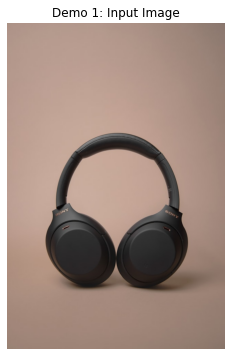

In [23]:
# Real product image: Sony WH-1000XM4 headphones (clearly branded)
DEMO_IMAGE_1 = "images/hp1.jpg"

# Show the image first
img1 = load_image(DEMO_IMAGE_1)
plt.figure(figsize=(6, 6))
plt.imshow(img1)
plt.axis("off")
plt.title("Demo 1: Input Image")
plt.show()

In [24]:
# Run the agent
result_1 = run_agent(
    image_sources=[DEMO_IMAGE_1],
    user_query="Analyze this product. Identify it, find the best price, check reviews, and get its specs. Give me a full analysis.",
    max_turns=5,
    verbose=True,
)


  TURN 1/5

  Thinking: The user wants me to analyze a product shown in an image.

1.  **Identify the product**: The image shows black over-ear headphones with the "SONY" logo. Based on the design, they look like Sony WH-100...
  Tool: search_product({'query': 'Sony noise canceling over-ear headphones black'})
  Result: {
  "product_name": "Sony WH-1000XM4",
  "brand": "Sony",
  "category": "Over-ear Wireless Headphones",
  "match_confidence": 0.95
}

  TURN 2/5

  Thinking: The user wants a full analysis of the product in the image.
I have identified the product as "Sony WH-1000XM4".
Now I need to get the price, reviews, and specifications.
According to the instructions,...
  Tool: get_price({'product_name': 'Sony WH-1000XM4'})
  Result: {
  "product_name": "Sony WH-1000XM4",
  "currency": "USD",
  "prices": [
    {
      "retailer": "Amazon",
      "price": 483.0,
      "in_stock": true
    },
    {
      "retailer": "Best Buy",
      "price": 507.15,
      "in_stock": true
    },
 

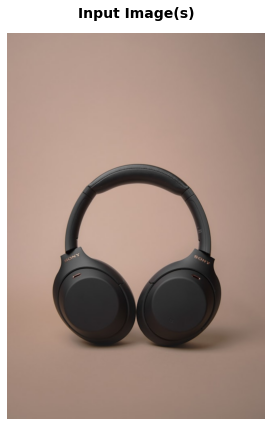

---
## Final Report
# Product Analysis Report: Sony WH-1000XM4

## Product Identification
- **Product Name:** Sony WH-1000XM4
- **Brand:** Sony
- **Category:** Over-ear Wireless Noise Canceling Headphones

## Price Comparison
| Retailer | Price (USD) | Availability |
| :--- | :--- | :--- |
| **B&H Photo** | **$468.51** | In Stock |
| Amazon | $483.00 | In Stock |
| Best Buy | $507.15 | In Stock |

**Best Value:** B&H Photo currently offers the lowest price at **$468.51**.

## Review Summary
- **Average Rating:** ⭐ 4.8 / 5 (based on 2,583 reviews)
- **Pros:**
    - Exceptional build quality
    - Extremely feature-rich (Multipoint connection, touch controls)
    - Strong overall value for the performance provided
- **Cons:**
    - Some users find them slightly heavy for long sessions
    - Some features have a learning curve for first-time users

## Key Specifications
| Feature | Specification |
| :--- | :--- |
| **Driver Size** | 40mm |
| **Frequency Response** | 4Hz - 40kHz |
| **Battery Life** | Up to 30 hours |
| **Weight** | 254g |
| **Noise Cancellation** | Dual Noise Sensor with Adaptive Sound Control |
| **Connectivity** | Bluetooth 5.0, NFC, 3.5mm jack, USB-C |
| **Supported Codecs** | SBC, AAC, LDAC |

## Recommendation & Value Assessment
**Recommendation: Highly Recommended**

The Sony WH-1000XM4 remains one of the top contenders in the noise-canceling headphone market. With a near-perfect user rating of 4.8/5, it balances industry-leading noise cancellation with high-fidelity audio support (LDAC). 

**Value Assessment:** 
Given the robust spec sheet and the competitive pricing (starting at ~$468), these headphones offer excellent value for professionals, frequent travelers, or audiophiles looking for a reliable, premium wireless experience. While newer models exist, the XM4 provides nearly identical performance and features at a more accessible price point.

In [25]:
# Visualize the trace and final report
visualize_agent_trace(result_1, images=[img1])

## 9. Demo 2: Headphones Comparison

Now let's give the agent two similar product images (both headphones) and ask it to compare them side-by-side.

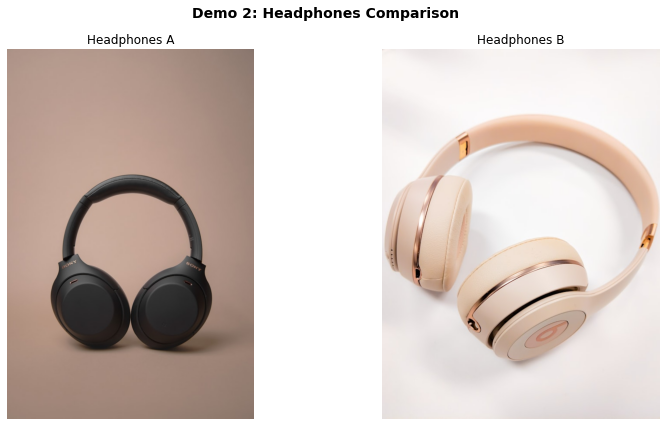

In [26]:
# Two branded headphones for comparison
# Sony WH-1000XM4 vs Beats Solo3
DEMO_IMAGE_2A = "images/hp1.jpg"
DEMO_IMAGE_2B = "images/hp3.jpg"

# Show both images
img2a = load_image(DEMO_IMAGE_2A)
img2b = load_image(DEMO_IMAGE_2B)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(img2a)
ax1.set_title("Headphones A")
ax1.axis("off")
ax2.imshow(img2b)
ax2.set_title("Headphones B")
ax2.axis("off")
plt.suptitle("Demo 2: Headphones Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [27]:
# Run the comparison agent
result_2 = run_agent(
    image_sources=[DEMO_IMAGE_2A, DEMO_IMAGE_2B],
    user_query=(
        "Compare these two products. For each one: identify it, look up pricing, "
        "reviews, and specs. Then give me a side-by-side comparison and tell me "
        "which is the better value."
    ),
    max_turns=5,
    verbose=True,
)


  TURN 1/5

  Thinking: The user wants a comparison of two products shown in images.
Image 1: Sony headphones (likely WH-1000XM series based on appearance).
Image 2: Beats headphones (likely Solo series, specifically Solo3 W...
  Tool: search_product({'query': 'Sony WH-1000XM4 headphones'})
  Result: {
  "product_name": "Sony WH-1000XM4",
  "brand": "Sony",
  "category": "Over-ear Wireless Headphones",
  "match_confidence": 0.95
}
  Tool: search_product({'query': 'Beats Solo3 Wireless headphones'})
  Result: {
  "product_name": "Beats Solo3 Wireless",
  "brand": "Beats",
  "category": "On-ear Wireless Headphones",
  "match_confidence": 0.93
}

  TURN 2/5

  Thinking: The user wants a comparison of the two products identified from the images: Sony WH-1000XM4 and Beats Solo3 Wireless.
I have already identified them using `search_product`.
Now, according to the syste...
  Tool: get_price({'product_name': 'Sony WH-1000XM4'})
  Result: {
  "product_name": "Sony WH-1000XM4",
  "currency": "

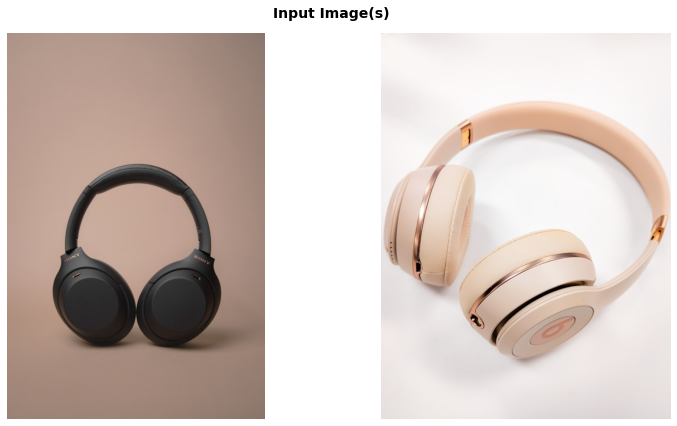

---
## Final Report
# Product Analysis Report: Sony WH-1000XM4 vs. Beats Solo3 Wireless

## 🎧 Product Identification
| Feature | Product 1 | Product 2 |
| :--- | :--- | :--- |
| **Name** | WH-1000XM4 | Solo3 Wireless |
| **Brand** | Sony | Beats |
| **Category** | Over-ear Wireless Headphones | On-ear Wireless Headphones |

---

## 💰 Price Comparison
| Retailer | Sony WH-1000XM4 | Beats Solo3 Wireless |
| :--- | :--- | :--- |
| **Amazon** | $483.00 | $360.00 |
| **Best Buy** | $507.15 | $378.00 |
| **B&H Photo** | **$468.51** | **$349.20** |
| **Lowest Price** | **$468.51** | **$349.20** |

---

## ⭐ Review Summary
| Metric | Sony WH-1000XM4 | Beats Solo3 Wireless |
| :--- | :--- | :--- |
| **Avg Rating** | 4.8 / 5 | 4.5 / 5 |
| **Pros** | Build quality, Feature-rich, Great value | Build quality, Feature-rich, Value |
| **Cons** | Weight, Feature learning curve | Weight, Feature learning curve |
| **Summary** | Exceptionally well-regarded for its noise cancellation and feature set. | Solid performance and strong brand appeal. |

---

## ⚙️ Key Specifications
| Specification | Sony WH-1000XM4 | Beats Solo3 Wireless |
| :--- | :--- | :--- |
| **Driver Size** | 40mm | Custom 40mm |
| **Freq. Response** | 4Hz - 40kHz | 20Hz - 31kHz |
| **Battery Life** | 30 Hours | **40 Hours** |
| **Noise Cancellation** | **Active (Dual Noise Sensor)** | Passive Isolation Only |
| **Connectivity** | BT 5.0, NFC, 3.5mm, USB-C | BT, Apple W1, 3.5mm |
| **Codecs** | SBC, AAC, LDAC (High-Res) | SBC, AAC |
| **Weight** | 254g | **215g** |

---

## 🎯 Recommendation & Value Assessment

### **The Verdict: Sony WH-1000XM4 is the Better Value**

While the **Beats Solo3 Wireless** is more affordable and offers longer battery life, the **Sony WH-1000XM4** provides a significantly superior technical experience that justifies its higher price point.

**Why choose Sony?**
*   **Industry-Leading ANC:** The Sony headphones feature active noise cancellation, whereas the Beats only offer passive isolation. This is a massive difference for commuting or office work.
*   **Audio Quality:** With a wider frequency response and support for the LDAC codec, the Sony offers a more "high-fidelity" listening experience.
*   **Comfort:** As an over-ear design, the Sony typically provides better long-term comfort than the on-ear pressure of the Beats.

**Why choose Beats?**
*   **Budget:** If you are looking to save ~$120.
*   **Apple Ecosystem:** The W1 chip allows for near-instant pairing with Apple devices.
*   **Portability:** They are slightly lighter and generally more compact.

**Final Value Assessment:** For the serious listener or traveler, the Sony WH-1000XM4 is a professional-grade tool. The Beats Solo3 are a stylish, capable lifestyle accessory, but they lack the critical features (ANC and High-Res audio) that make the Sony a gold standard in the industry.

In [28]:
# Visualize comparison trace and report
visualize_agent_trace(result_2, images=[img2a, img2b])

## 10. Try Your Own Image

Drop in any product image URL or local path and run the agent on it.

In [ ]:
# YOUR_IMAGE = "https://example.com/your-product.jpg"  # or "/path/to/local/image.jpg"
# YOUR_QUERY = "What is this product? Give me a full analysis."
#
# your_img = load_image(YOUR_IMAGE)
# your_result = run_agent(
#     image_sources=[YOUR_IMAGE],
#     user_query=YOUR_QUERY,
#     max_turns=5,
#     verbose=True,
# )
# visualize_agent_trace(your_result, images=[your_img])